<a href="https://colab.research.google.com/github/oscar2121/AZ2003/blob/master/Redes_Neuronales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Práctica de Machine Learning & Deep Learning: Redes Neuronales Basicas

### Objetivos:
1. Comprender la transición matemática de Machine Learning clásico a Deep Learning.
2. Implementar la regla de aprendizaje del **Perceptrón de Rosenblatt**.
3. Construir una **Red Neuronal de una sola capa** (regresión logística/activación continua).
4. Implementar un **Perceptrón Multicapa (MLP)** resolviendo el problema no lineal XOR mediante **Forward Propagation** y **Backpropagation** con cálculo matricial (NumPy).
5. Demostrar la eficiencia de la **vectorización** frente a bucles iterativos tradicionales.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Fijar semilla para reproducibilidad matemática
np.random.seed(42)
print(f"NumPy versión: {np.__version__}")

NumPy versión: 2.1.3




## 1. El Perceptrón Simple (Rosenblatt, 1958)
El perceptrón modela una sola neurona biológica. Realiza una combinación lineal de entradas ponderadas por pesos sinápticos más un sesgo (*bias*):
$$z = \mathbf{w} \cdot \mathbf{x} + b = \sum_{i=1}^{n} w_i x_i + b$$

Se aplica una función de activación escalón (*Heaviside*):
$$f(z) = \begin{cases} 1 & \text{si } z \ge 0 \\ 0 & \text{si } z < 0 \end{cases}$$

**Regla de actualización de pesos:**
$$\mathbf{w} \leftarrow \mathbf{w} + \eta (y - \hat{y}) \mathbf{x}$$
$$b \leftarrow b + \eta (y - \hat{y})$$
Donde $\eta$ es la tasa de aprendizaje (*learning rate*).



In [ ]:
class PerceptronVanilla:
    def __init__(self, n_inputs, lr=0.1, epochs=20):
        self.lr = lr
        self.epochs = epochs
        # Inicialización de pesos en cero o valores pequeños
        self.weights = np.zeros(n_inputs)
        self.bias = 0.0
        self.errors_history = []

    def activation(self, z):
        # Función escalón unitario vectorizada
        return np.where(z >= 0, 1, 0)

    def predict(self, X):
        # Producto punto matricial: z = X @ w + b
        z = np.dot(X, self.weights) + self.bias
        return self.activation(z)

    def fit(self, X, y):
        for epoch in range(self.epochs):
            total_error = 0
            for xi, target in zip(X, y):
                pred = self.activation(np.dot(xi, self.weights) + self.bias)
                update = self.lr * (target - pred)
                self.weights += update * xi
                self.bias += update
                total_error += int(update != 0.0)
            self.errors_history.append(total_error)
            if total_error == 0:
                print(f"[Perceptrón] Convergió en la época {epoch+1}")
                break

# Datos: Compuerta lógica AND (linealmente separable)
X_and = np.array([[0, 0],
                  [0, 1],
                  [1, 0],
                  [1, 1]])
y_and = np.array([0, 0, 0, 1])

# Entrenamiento
p = PerceptronVanilla(n_inputs=2, lr=0.1, epochs=10)
p.fit(X_and, y_and)

print(f"Pesos finales: {p.weights}, Sesgo final: {p.bias}")
print(f"Predicciones para AND: {p.predict(X_and)} (Esperado: {y_and})")

[Perceptrón] Convergió en la época 4
Pesos finales: [0.2 0.1], Sesgo final: -0.20000000000000004
Predicciones para AND: [0 0 0 1] (Esperado: [0 0 0 1])


## 2. Red Neuronal de Una Capa con Activación Sigmoide
Para permitir la optimización mediante descenso de gradiente continuo, sustituimos la función escalón discontinua por una función derivable, como la **Sigmoide**:
$$\sigma(z) = \frac{1}{1 + e^{-z}}$$
Su derivada matemática es:
$$\sigma'(z) = \sigma(z)(1 - \sigma(z))$$

### Vectorización de Lote Completo (Batch Vectorization):
Si $X \in \mathbb{R}^{m \times n}$ (donde $m$ es el número de muestras y $n$ características) y $W \in \mathbb{R}^{n \times 1}$:
$$Z = X W + b \in \mathbb{R}^{m \times 1}$$
$$\hat{Y} = \sigma(Z)$$

El gradiente con respecto a los pesos se calcula en una sola operación matricial:
$$\frac{\partial L}{\partial W} = \frac{1}{m} X^T (\hat{Y} - Y)$$

In [ ]:
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

def sigmoid_derivative(a):
    # a = sigmoid(z)
    return a * (1.0 - a)

class SingleLayerNetwork:
    def __init__(self, n_features, lr=0.5, epochs=1000):
        self.lr = lr
        self.epochs = epochs
        # Inicialización uniforme pequeña
        self.W = np.random.randn(n_features, 1) * 0.01
        self.b = np.zeros((1, 1))
        self.loss_history = []

    def fit(self, X, y):
        m = X.shape[0]
        y = y.reshape(-1, 1)

        for epoch in range(self.epochs):
            # 1. Forward pass vectorizado
            Z = np.dot(X, self.W) + self.b
            A = sigmoid(Z)

            # Error Cuadrático Medio (MSE)
            loss = np.mean((A - y) ** 2)
            self.loss_history.append(loss)

            # 2. Backpropagation (Gradiente MSE + Sigmoide)
            # dL/dA = 2*(A - y)/m, dA/dZ = A*(1 - A)
            dZ = (A - y) * sigmoid_derivative(A)
            dW = (1.0 / m) * np.dot(X.T, dZ)
            db = (1.0 / m) * np.sum(dZ, axis=0, keepdims=True)

            # 3. Actualización por Descenso de Gradiente
            self.W -= self.lr * dW
            self.b -= self.lr * db

    def predict(self, X):
        A = sigmoid(np.dot(X, self.W) + self.b)
        return (A >= 0.5).astype(int)

# Datos: Compuerta OR
X_or = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y_or = np.array([0, 1, 1, 1])

sln = SingleLayerNetwork(n_features=2, lr=1.0, epochs=1500)
sln.fit(X_or, y_or)

preds_or = sln.predict(X_or).flatten()
print(f"Predicciones OR: {preds_or} (Esperado: {y_or})")
print(f"Pérdida final (MSE): {sln.loss_history[-1]:.6f}")

Predicciones OR: [0 1 1 1] (Esperado: [0 1 1 1])
Pérdida final (MSE): 0.004024


## 3. Red Neuronal Multicapa (MLP) y el Problema XOR
Una sola neurona no puede clasificar datos no linealmente separables (como la compuerta **XOR**). Para resolver esto, se implementa una capa oculta (*hidden layer*) que proyecta el espacio de entrada en una nueva representación dimensionalmente separable.

### Arquitectura de la Red:
- **Capa de entrada:** 2 neuronas ($X$)
- **Capa oculta:** 4 neuronas ($W_1, b_1$) con activación Sigmoide.
- **Capa de salida:** 1 neurona ($W_2, b_2$) con activación Sigmoide.

### Ecuaciones Matriciales:
1. **Forward Pass:**
   $$Z_1 = X W_1 + b_1 \quad \in \mathbb{R}^{m \times 4}$$
   $$A_1 = \sigma(Z_1)$$
   $$Z_2 = A_1 W_2 + b_2 \quad \in \mathbb{R}^{m \times 1}$$
   $$A_2 = \sigma(Z_2) \quad (\hat{Y})$$

2. **Backward Pass (Regla de la Cadena):**
   $$\delta_2 = (A_2 - Y) \odot \sigma'(A_2)$$
   $$\frac{\partial L}{\partial W_2} = \frac{1}{m} A_1^T \delta_2, \quad \frac{\partial L}{\partial b_2} = \frac{1}{m} \sum \delta_2$$
   $$\delta_1 = (\delta_2 W_2^T) \odot \sigma'(A_1)$$
   $$\frac{\partial L}{\partial W_1} = \frac{1}{m} X^T \delta_1, \quad \frac{\partial L}{\partial b_1} = \frac{1}{m} \sum \delta_1$$

In [ ]:
class MultilayerPerceptronVanilla:
    def __init__(self, input_dim, hidden_dim, output_dim, lr=0.5):
        self.lr = lr
        # Inicialización de pesos (He / Xavier básico)
        self.W1 = np.random.randn(input_dim, hidden_dim) * np.sqrt(2.0 / input_dim)
        self.b1 = np.zeros((1, hidden_dim))
        self.W2 = np.random.randn(hidden_dim, output_dim) * np.sqrt(2.0 / hidden_dim)
        self.b2 = np.zeros((1, output_dim))
        self.loss_history = []

    def forward(self, X):
        self.Z1 = np.dot(X, self.W1) + self.b1
        self.A1 = sigmoid(self.Z1)
        self.Z2 = np.dot(self.A1, self.W2) + self.b2
        self.A2 = sigmoid(self.Z2)
        return self.A2

    def backward(self, X, y):
        m = X.shape[0]

        # Gradientes de la capa de salida
        dA2 = (self.A2 - y)
        dZ2 = dA2 * sigmoid_derivative(self.A2)
        dW2 = (1.0 / m) * np.dot(self.A1.T, dZ2)
        db2 = (1.0 / m) * np.sum(dZ2, axis=0, keepdims=True)

        # Gradientes de la capa oculta (propagación del error)
        dA1 = np.dot(dZ2, self.W2.T)
        dZ1 = dA1 * sigmoid_derivative(self.A1)
        dW1 = (1.0 / m) * np.dot(X.T, dZ1)
        db1 = (1.0 / m) * np.sum(dZ1, axis=0, keepdims=True)

        # Actualización de pesos
        self.W2 -= self.lr * dW2
        self.b2 -= self.lr * db2
        self.W1 -= self.lr * dW1
        self.b1 -= self.lr * db1

    def fit(self, X, y, epochs=10000):
        y = y.reshape(-1, 1)
        for epoch in range(epochs):
            A2 = self.forward(X)
            # Binary Cross Entropy Loss
            loss = -np.mean(y * np.log(A2 + 1e-8) + (1 - y) * np.log(1 - A2 + 1e-8))
            self.loss_history.append(loss)
            self.backward(X, y)

    def predict(self, X):
        prob = self.forward(X)
        return (prob >= 0.5).astype(int), prob

# Datos: Compuerta lógica XOR (Problema NO lineal)
X_xor = np.array([[0, 0],
                  [0, 1],
                  [1, 0],
                  [1, 1]])
y_xor = np.array([0, 1, 1, 0])

# Instanciar y entrenar MLP
mlp = MultilayerPerceptronVanilla(input_dim=2, hidden_dim=4, output_dim=1, lr=1.0)
mlp.fit(X_xor, y_xor, epochs=5000)

pred_classes, pred_probs = mlp.predict(X_xor)

print("--- RESULTADOS COMPUERTA XOR ---")
for i in range(len(X_xor)):
    print(f"Entrada: {X_xor[i]} | Probabilidad: {pred_probs[i][0]:.4f} | Predicción: {pred_classes[i][0]} | Esperado: {y_xor[i]}")

--- RESULTADOS COMPUERTA XOR ---
Entrada: [0 0] | Probabilidad: 0.0379 | Predicción: 0 | Esperado: 0
Entrada: [0 1] | Probabilidad: 0.9636 | Predicción: 1 | Esperado: 1
Entrada: [1 0] | Probabilidad: 0.9631 | Predicción: 1 | Esperado: 1
Entrada: [1 1] | Probabilidad: 0.0422 | Predicción: 0 | Esperado: 0


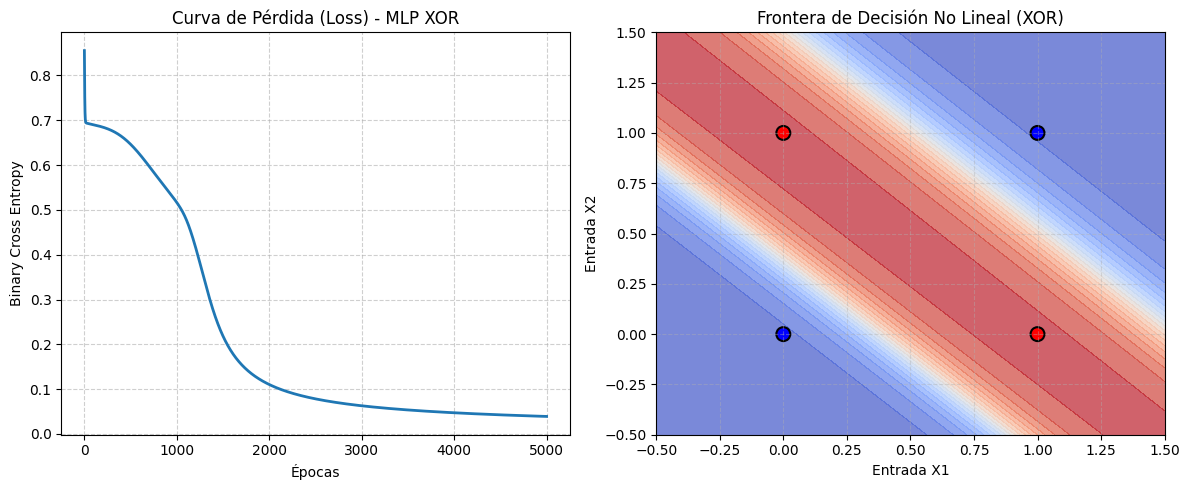

In [ ]:
# Gráfica de convergencia de la función de pérdida
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(mlp.loss_history, color='#1f77b4', lw=2)
plt.title("Curva de Pérdida (Loss) - MLP XOR")
plt.xlabel("Épocas")
plt.ylabel("Binary Cross Entropy")
plt.grid(True, linestyle='--', alpha=0.6)

# Gráfica de frontera de decisión no lineal
plt.subplot(1, 2, 2)
x_min, x_max = -0.5, 1.5
y_min, y_max = -0.5, 1.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))
grid_data = np.c_[xx.ravel(), yy.ravel()]
_, grid_preds = mlp.predict(grid_data)
grid_preds = grid_preds.reshape(xx.shape)

plt.contourf(xx, yy, grid_preds, levels=20, cmap="coolwarm", alpha=0.7)
plt.scatter(X_xor[:, 0], X_xor[:, 1], c=y_xor, cmap="bwr", edgecolors="black", s=100, linewidth=1.5)
plt.title("Frontera de Decisión No Lineal (XOR)")
plt.xlabel("Entrada X1")
plt.ylabel("Entrada X2")
plt.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

### Síntesis y Conclusiones:
1. **Límites del Perceptrón Simple:** El algoritmo original de Rosenblatt está restringido a problemas linealmente separables (AND, OR). Falla ante relaciones no lineales como XOR debido a la ausencia de capas intermedias capaces de deformar el espacio de características.
2. **Importancia de la Derivabilidad:** Para abandonar el ajuste empírico y utilizar el **Descenso de Gradiente**, es indispensable contar con funciones de activación suaves y diferenciables (como Sigmoide, ReLU o Tanh).
3. **Eficiencia con Vectorización en NumPy:** Las operaciones sobre lotes de datos completados con productos matriciales (`np.dot`, `X @ W`) aprovechan las optimizaciones a bajo nivel en C/BLAS de NumPy. Esto elimina la sobrecarga de bucles `for` explícitos por muestra, permitiendo procesar redes neuronales con alta velocidad y código conciso.
4. **Fundamentos de Deep Learning:** La arquitectura multicapa (MLP) modela cualquier función continua compleja gracias al teorema de aproximación universal, operando mediante la concatenación de transformaciones afines y no linealidades sucesivas.